# Análisis textual básico del corpus exportado

Medidas textuales, frecuencias de palabras y dos visualizaciones simples sobre
`exports/corpus.parquet`. No reemplaza a `03-analisis-del-corpus.ipynb` —ese
notebook cubre énfasis temático, léxico comparado entre medios y candidatos a
"mismo hecho"— sino que cubre la estadística descriptiva de texto que falta
ahí: conteo de palabras y frecuencias léxicas del corpus como un todo.

Requisitos: `news-corpus export -o exports/corpus.parquet` ya ejecutado y el
paquete instalado con el extra `notebook`
(`uv pip install -e ".[dev,export,notebook]"`, o `docker compose build
jupyter` si se usa el servicio de Docker — se agregó `wordcloud` al extra).

**Fuente de texto: el cuerpo del artículo (`content`), no el titular.** Su
cobertura es muy desigual entre medios —El Tiempo ~99 %, Blu Radio y Noticias
Caracol muy por debajo, y no es una muestra aleatoria (ver README, sección
"Qué lleva el export")—, así que las medidas de este notebook describen sobre
todo a El Tiempo, no al corpus completo. Queda anotado en la celda 1 con
cifras concretas, no como advertencia genérica.

In [1]:
from pathlib import Path

import pandas as pd

# El kernel arranca con cwd = carpeta del notebook (notebooks/), no la raíz
# del repo, así que se prueban ambas ubicaciones.
CORPUS = next(
    (p for p in (Path("exports/corpus.parquet"), Path("../exports/corpus.parquet")) if p.exists()),
    None,
)
if CORPUS is None:
    raise SystemExit("Falta el export. Ejecuta: news-corpus export -o exports/corpus.parquet")

df = pd.read_parquet(CORPUS)

# Mismo umbral que 03-analisis-del-corpus.ipynb: por debajo de esto el
# "cuerpo" suele ser interfaz de página (reproductor, navegación), no artículo.
CUERPO_MINIMO = 500

analizable = df[df["content_chars"] >= CUERPO_MINIMO].copy()

print(f"{len(df):,} artículos en el export")
print(f"{len(analizable):,} con cuerpo analizable (≥{CUERPO_MINIMO} caracteres)\n")
print(analizable["source_name"].value_counts().to_string())

17,202 artículos en el export
7,567 con cuerpo analizable (≥500 caracteres)

source_name
El Tiempo           4996
Noticias Caracol    1481
Blu Radio           1090


---

## 1. Medidas textuales

Documentos, palabras totales y promedio de palabras por documento, sobre el
subconjunto con cuerpo analizable.

In [2]:
import re


def tokenizar(texto):
    """Minúsculas, sólo palabras (con tildes y ñ). Sin normalizar acentos:
    a diferencia de los títulos, el cuerpo extraído no viene de un slug de
    URL, así que las tildes son las que escribió el medio.
    """
    if not isinstance(texto, str):
        return []
    return re.findall(r"[a-záéíóúüñ]+", texto.lower())


analizable["tokens"] = analizable["content"].map(tokenizar)
analizable["n_palabras"] = analizable["tokens"].map(len)

n_documentos = len(analizable)
total_palabras = int(analizable["n_palabras"].sum())
promedio_palabras = total_palabras / n_documentos

print(f"Documentos analizados     : {n_documentos:,}")
print(f"Palabras totales          : {total_palabras:,}")
print(f"Promedio de palabras/doc  : {promedio_palabras:,.1f}")

Documentos analizados     : 7,567
Palabras totales          : 3,141,713
Promedio de palabras/doc  : 415.2


In [3]:
# Desglose por medio: el promedio global esconde que no todos escriben igual
# de largo, y que casi todo el volumen es de un solo medio (ver celda 1).
(
    analizable.groupby("source_name")
    .agg(documentos=("n_palabras", "count"),
         palabras_totales=("n_palabras", "sum"),
         promedio_palabras=("n_palabras", "mean"))
    .round(1)
    .sort_values("documentos", ascending=False)
)

,documentos,palabras_totales,promedio_palabras
source_name,,,
El Tiempo,4996,2531771,506.8
Noticias Caracol,1481,405041,273.5
Blu Radio,1090,204901,188.0


---

## 2. Frecuencias de palabras

Top 20 con stopwords (domina la gramática: artículos, preposiciones, formas
de *ser*/*estar*/*haber*) y top 20 sin ellas (empieza a verse el contenido).
La lista de stopwords sale del corpus `stopwords` de NLTK (`nltk.corpus.stopwords.words("spanish")`),
no de una lista copiada a mano. Se le suma un puñado de palabras que NLTK no
trae —*ser*, *dijo*, *según*, *puede*, *solo*, *así*, entre otras— y que se
detectaron colándose en el top 20 de la primera corrida: verbos y marcadores
de discurso típicos del lenguaje periodístico que la lista estándar no cubre.

In [4]:
from collections import Counter

import nltk
from nltk.corpus import stopwords as nltk_stopwords

try:
    STOPWORDS = set(nltk_stopwords.words("spanish"))
except LookupError:
    # No debería faltar en el contenedor de Jupyter -el corpus se descarga en
    # build time, ver Dockerfile.jupyter- pero corriendo en el host puede no
    # estar la primera vez.
    nltk.download("stopwords")
    STOPWORDS = set(nltk_stopwords.words("spanish"))

# Fuera del alcance de NLTK: verbos y marcadores de discurso frecuentes en
# noticias que se colaban en el top 20 "sin stopwords" de la primera corrida.
STOPWORDS |= {
    "ser", "dijo", "dijeron", "según", "puede", "pueden", "solo", "sólo",
    "así", "además", "afirmó", "señaló", "pues", "mismo", "misma", "mismos",
    "mismas", "aunque", "incluso", "sino", "cada", "hace", "hacia", "hacer",
    "hizo", "hicieron",
}

print(f"{len(STOPWORDS)} stopwords (NLTK + extensión manual, español)")


def frecuencias(tokens_series):
    c = Counter()
    for tokens in tokens_series:
        c.update(tokens)
    return c


todas = frecuencias(analizable["tokens"])
sin_stopwords = Counter({
    palabra: n for palabra, n in todas.items()
    if palabra not in STOPWORDS and len(palabra) > 2
})

top20_con = pd.DataFrame(todas.most_common(20), columns=["palabra", "frecuencia"])
top20_sin = pd.DataFrame(sin_stopwords.most_common(20), columns=["palabra", "frecuencia"])

print("Top 20 con stopwords:")
print(top20_con.to_string(index=False))
print("\nTop 20 sin stopwords:")
print(top20_sin.to_string(index=False))

339 stopwords (NLTK + extensión manual, español)


Top 20 con stopwords:
palabra  frecuencia
     de      209908
     la      128715
     el      109111
    que      101316
     en       97447
      y       83636
      a       65911
    los       52179
    del       42948
     se       37235
    por       34951
    las       33189
     un       33014
    con       32753
   para       29007
    una       26495
     no       24509
     su       21592
     es       21326
     al       18918

Top 20 sin stopwords:
    palabra  frecuencia
       años        6000
        dos        5097
       país        4590
   colombia        4522
     tiempo        4095
información        3659
      parte        3588
   gobierno        3456
        año        3243
 presidente        3056
   millones        2949
     ciento        2916
     cuenta        2859
     pasado        2840
   personas        2752
    después        2639
     bogotá        2632
   nacional        2618
       tres        2515
        vez        2322


---

## 3. Visualizaciones

Gráfico de barras y nube de palabras, ambos sobre las frecuencias **sin
stopwords** — con ellas, cualquiera de los dos queda dominado por "de", "la",
"que" y no dice nada del contenido.

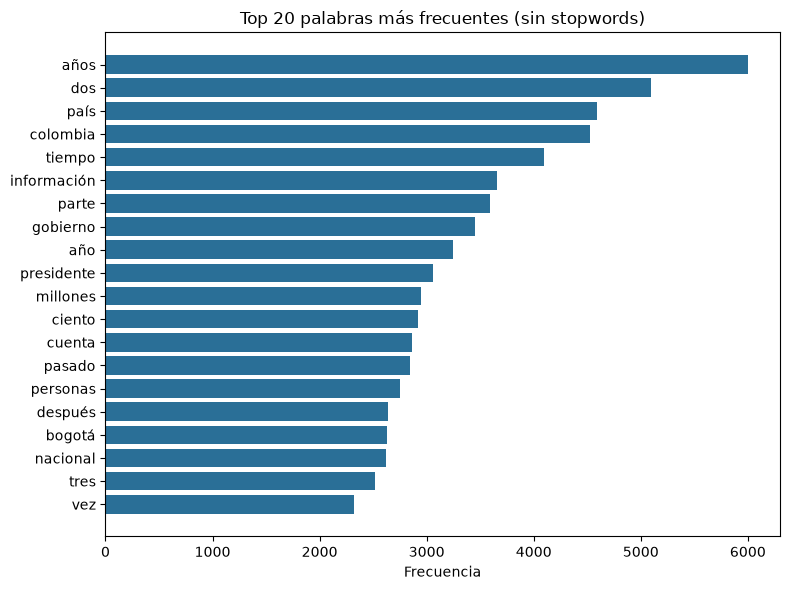

In [5]:
import matplotlib.pyplot as plt

orden = top20_sin.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(orden["palabra"], orden["frecuencia"], color="#2a6f97")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 20 palabras más frecuentes (sin stopwords)")
fig.tight_layout()
plt.show()

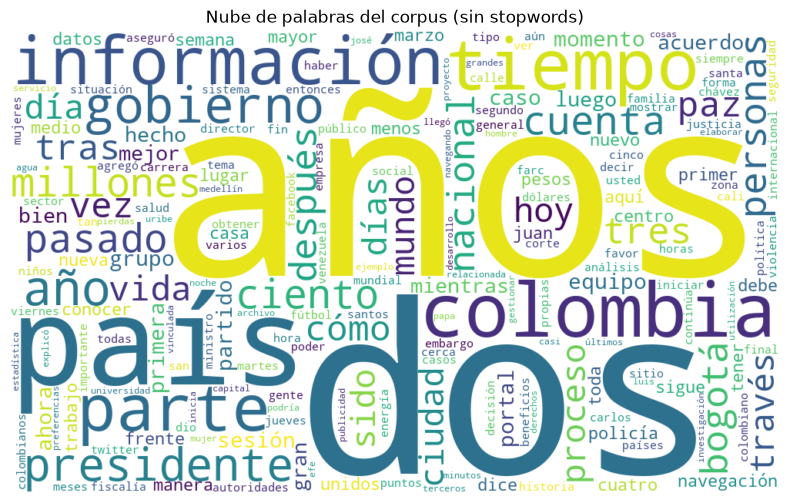

In [6]:
from wordcloud import WordCloud

nube = WordCloud(
    width=1000, height=600, background_color="white", colormap="viridis"
).generate_from_frequencies(dict(sin_stopwords))

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(nube, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras del corpus (sin stopwords)")
plt.show()